In [1]:
!pip install mediapipe opencv-python-headless pandas numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
!pip uninstall mediapipe -y
!pip install -U mediapipe==0.10.13

Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.2

In [3]:
import mediapipe as mp
print(mp.__version__)
print(mp.__file__)
print(hasattr(mp, "solutions"))

0.10.13
/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import cv2
import math
import numpy as np
import pandas as pd
from pathlib import Path
import mediapipe as mp
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2

In [6]:
video_path = "/content/drive/MyDrive/CREATE Lab/video_agent360/autocrop_out/person_slot0_640x900.mp4"
output_csv = "/content/drive/MyDrive/CREATE Lab/video_agent360/features_person_slot0.csv"

In [7]:
mp_face_mesh = mp.solutions.face_mesh
mp_pose = mp.solutions.pose

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [8]:
def dist2(p1, p2):
    return float(np.linalg.norm(np.array(p1) - np.array(p2)))

def safe_get_landmark(landmarks, idx, w, h):
    lm = landmarks[idx]
    return np.array([lm.x * w, lm.y * h], dtype=np.float32)

def compute_face_features(face_landmarks, w, h):
    """
    返回:
    yaw_proxy
    pitch_proxy
    smile_score
    mouth_open_score
    """
    # 关键点索引（MediaPipe FaceMesh）
    # nose tip: 1
    # left eye outer-ish: 33
    # right eye outer-ish: 263
    # mouth left: 61
    # mouth right: 291
    # upper lip: 13
    # lower lip: 14
    # chin-ish: 152

    pts = face_landmarks.landmark

    nose = safe_get_landmark(pts, 1, w, h)
    left_eye = safe_get_landmark(pts, 33, w, h)
    right_eye = safe_get_landmark(pts, 263, w, h)
    mouth_l = safe_get_landmark(pts, 61, w, h)
    mouth_r = safe_get_landmark(pts, 291, w, h)
    upper_lip = safe_get_landmark(pts, 13, w, h)
    lower_lip = safe_get_landmark(pts, 14, w, h)
    chin = safe_get_landmark(pts, 152, w, h)

    eye_center = (left_eye + right_eye) / 2.0
    mouth_center = (mouth_l + mouth_r) / 2.0
    face_center = (eye_center + mouth_center) / 2.0

    # ---------- yaw proxy ----------
    # nose 相对双眼中点左右偏移
    eye_width = dist2(left_eye, right_eye) + 1e-6
    yaw_proxy = (nose[0] - eye_center[0]) / eye_width

    # ---------- pitch proxy ----------
    # nose 在 eye_center 和 mouth_center 之间的位置关系
    # 头低时，nose 往下偏；头抬时，nose 往上偏
    face_height_ref = dist2(eye_center, mouth_center) + 1e-6
    pitch_proxy = (nose[1] - eye_center[1]) / face_height_ref

    # ---------- smile score ----------
    mouth_width = dist2(mouth_l, mouth_r)
    mouth_open = dist2(upper_lip, lower_lip)
    jaw_height = dist2(eye_center, chin) + 1e-6

    smile_score = mouth_width / jaw_height
    mouth_open_score = mouth_open / jaw_height

    return {
        "yaw_proxy": float(yaw_proxy),
        "pitch_proxy": float(pitch_proxy),
        "smile_score": float(smile_score),
        "mouth_open_score": float(mouth_open_score),
    }

def compute_pose_features(pose_landmarks, w, h):
    """
    返回左右手腕位置（归一化）和可用于 take_notes 的信息
    """
    pts = pose_landmarks.landmark
    mp_pose_lm = mp.solutions.pose.PoseLandmark

    def get_xy(name):
        idx = mp_pose_lm[name].value
        lm = pts[idx]
        return np.array([lm.x, lm.y], dtype=np.float32), float(lm.visibility)

    left_wrist, left_wrist_vis = get_xy("LEFT_WRIST")
    right_wrist, right_wrist_vis = get_xy("RIGHT_WRIST")
    left_elbow, left_elbow_vis = get_xy("LEFT_ELBOW")
    right_elbow, right_elbow_vis = get_xy("RIGHT_ELBOW")
    left_shoulder, left_shoulder_vis = get_xy("LEFT_SHOULDER")
    right_shoulder, right_shoulder_vis = get_xy("RIGHT_SHOULDER")

    return {
        "left_wrist_x": float(left_wrist[0]),
        "left_wrist_y": float(left_wrist[1]),
        "right_wrist_x": float(right_wrist[0]),
        "right_wrist_y": float(right_wrist[1]),
        "left_wrist_vis": float(left_wrist_vis),
        "right_wrist_vis": float(right_wrist_vis),
        "left_elbow_y": float(left_elbow[1]),
        "right_elbow_y": float(right_elbow[1]),
        "left_shoulder_y": float(left_shoulder[1]),
        "right_shoulder_y": float(right_shoulder[1]),
    }

In [ ]:
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30.0

records = []
frame_idx = 0

prev_left_wrist = None
prev_right_wrist = None
prev_t = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    t = frame_idx / fps
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    face_res = face_mesh.process(rgb)
    pose_res = pose.process(rgb)

    row = {
        "frame_idx": frame_idx,
        "t": float(t),
        "face_detected": 0,
        "pose_detected": 0,
        "yaw_proxy": np.nan,
        "pitch_proxy": np.nan,
        "smile_score": np.nan,
        "mouth_open_score": np.nan,
        "left_wrist_x": np.nan,
        "left_wrist_y": np.nan,
        "right_wrist_x": np.nan,
        "right_wrist_y": np.nan,
        "left_wrist_vis": np.nan,
        "right_wrist_vis": np.nan,
        "left_elbow_y": np.nan,
        "right_elbow_y": np.nan,
        "left_shoulder_y": np.nan,
        "right_shoulder_y": np.nan,
        "left_wrist_speed": np.nan,
        "right_wrist_speed": np.nan,
    }

    # ---- face features ----
    if face_res.multi_face_landmarks:
        face_lms = face_res.multi_face_landmarks[0]
        face_feats = compute_face_features(face_lms, w, h)
        row.update(face_feats)
        row["face_detected"] = 1

    # ---- pose features ----
    if pose_res.pose_landmarks:
        pose_feats = compute_pose_features(pose_res.pose_landmarks, w, h)
        row.update(pose_feats)
        row["pose_detected"] = 1

        # wrist speed
        if prev_t is not None:
            dt = t - prev_t
            if dt > 1e-6:
                cur_left = np.array([row["left_wrist_x"], row["left_wrist_y"]], dtype=np.float32)
                cur_right = np.array([row["right_wrist_x"], row["right_wrist_y"]], dtype=np.float32)

                if prev_left_wrist is not None and not np.any(np.isnan(cur_left)):
                    row["left_wrist_speed"] = float(np.linalg.norm(cur_left - prev_left_wrist) / dt)

                if prev_right_wrist is not None and not np.any(np.isnan(cur_right)):
                    row["right_wrist_speed"] = float(np.linalg.norm(cur_right - prev_right_wrist) / dt)

        prev_left_wrist = np.array([row["left_wrist_x"], row["left_wrist_y"]], dtype=np.float32)
        prev_right_wrist = np.array([row["right_wrist_x"], row["right_wrist_y"]], dtype=np.float32)
        prev_t = t

    records.append(row)
    frame_idx += 1

cap.release()

df = pd.DataFrame(records)
print(df.head())
print("num frames:", len(df))

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [16]:
Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_csv, index=False)
print("saved to:", output_csv)

saved to: /content/drive/MyDrive/CREATE Lab/video_agent360/features_person_slot0.csv


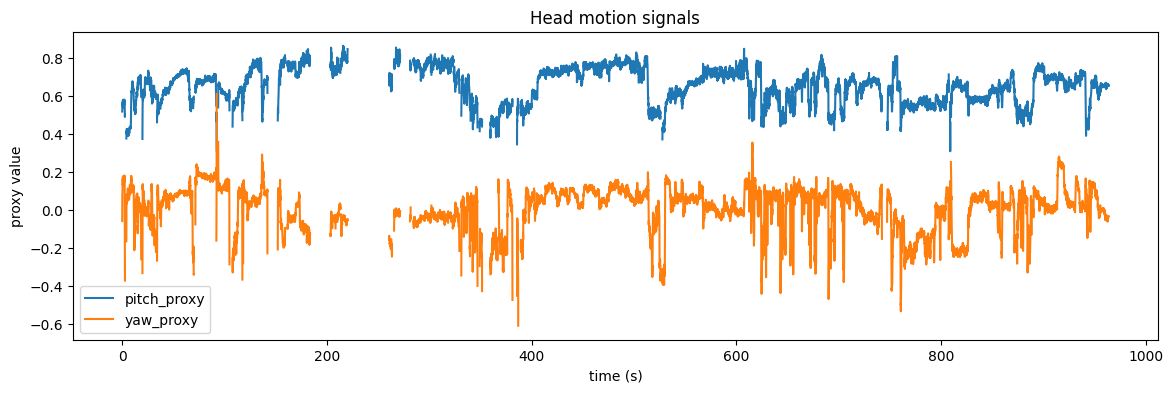

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df["t"], df["pitch_proxy"], label="pitch_proxy")
plt.plot(df["t"], df["yaw_proxy"], label="yaw_proxy")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("proxy value")
plt.title("Head motion signals")
plt.show()

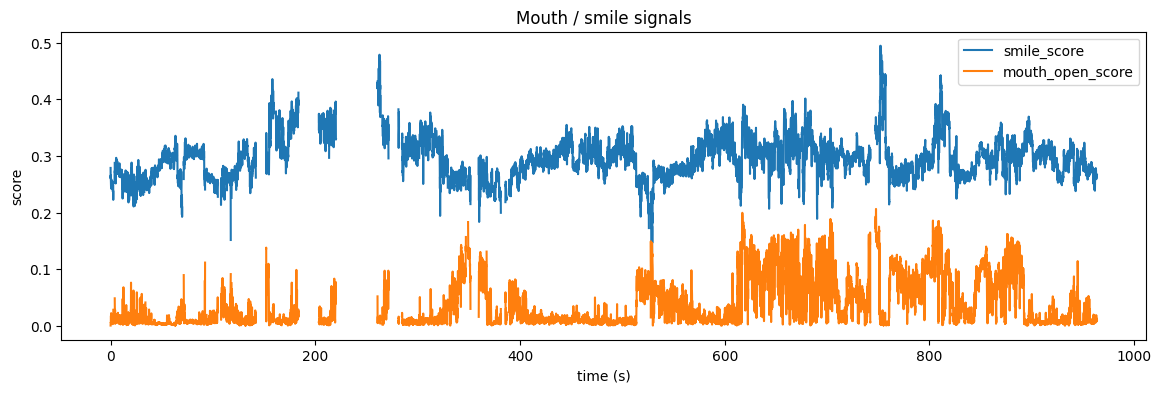

In [18]:
plt.figure(figsize=(14,4))
plt.plot(df["t"], df["smile_score"], label="smile_score")
plt.plot(df["t"], df["mouth_open_score"], label="mouth_open_score")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("score")
plt.title("Mouth / smile signals")
plt.show()

In [19]:
df["look_down_flag"] = df["pitch_proxy"] > 1.15
df["look_up_flag"] = df["pitch_proxy"] < 0.85

In [20]:
window = 15  # 约 0.5s，如果视频30fps
df["pitch_range"] = df["pitch_proxy"].rolling(window, min_periods=5).max() - df["pitch_proxy"].rolling(window, min_periods=5).min()
df["head_nodding_flag"] = df["pitch_range"] > 0.18

In [21]:
df["look_down_flag"] = df["pitch_proxy"] > 1.15
df["hand_near_bottom"] = (df["left_wrist_y"] > 0.65) | (df["right_wrist_y"] > 0.65)
df["hand_moving"] = (df["left_wrist_speed"] > 0.02) | (df["right_wrist_speed"] > 0.02)
df["take_notes_flag"] = df["look_down_flag"] & df["hand_near_bottom"] & df["hand_moving"]

Text(0.5, 1.0, 'face detected flag')

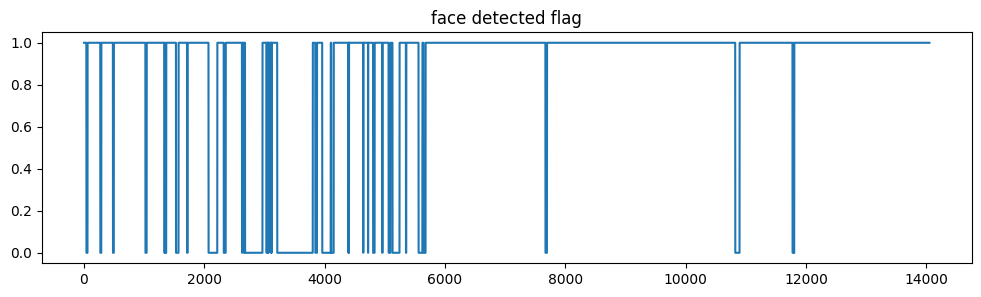

In [22]:
plt.figure(figsize=(12,3))
plt.plot(df["face_detected"])
plt.title("face detected flag")

In [ ]:
'''
df["yaw_proxy"] = df["yaw_proxy"].interpolate()
df["pitch_proxy"] = df["pitch_proxy"].interpolate()
'''

In [24]:
df

,frame_idx,t,face_detected,pose_detected,yaw_proxy,pitch_proxy,smile_score,mouth_open_score,left_wrist_x,left_wrist_y,...,right_shoulder_y,left_wrist_speed,right_wrist_speed,look_down_flag,look_up_flag,pitch_range,head_nodding_flag,hand_near_bottom,hand_moving,take_notes_flag
0,0,0.000000,1,1,-0.057497,0.519073,0.278825,0.000337,0.757487,0.893516,...,0.643382,NaN,NaN,False,True,NaN,False,True,False,False
1,1,0.068573,1,1,0.049977,0.537860,0.260075,0.003409,0.757570,0.894371,...,0.650322,0.012520,0.009935,False,True,NaN,False,True,False,False
2,2,0.137146,1,1,0.086832,0.538086,0.265799,0.006043,0.757565,0.894409,...,0.654350,0.000556,0.049931,False,True,NaN,False,True,True,False
3,3,0.205719,1,1,0.091030,0.554598,0.259694,0.005194,0.740058,0.883029,...,0.657004,0.304501,0.012248,False,True,NaN,False,True,True,False
4,4,0.274292,1,1,0.125500,0.554111,0.262697,0.006194,0.706773,0.883450,...,0.657268,0.485431,0.184798,False,True,0.035525,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14049,14049,963.382020,1,1,-0.031217,0.656283,0.264287,0.010068,0.603030,0.899115,...,0.652396,0.001874,0.016335,False,True,0.012101,False,True,False,False
14050,14050,963.450593,1,1,-0.034747,0.662222,0.265135,0.008932,0.602944,0.899100,...,0.652361,0.001272,0.007092,False,True,0.012101,False,True,False,False
14051,14051,963.519166,1,1,-0.034552,0.656491,0.267599,0.009717,0.602914,0.899068,...,0.652335,0.000641,0.000758,False,True,0.009130,False,True,False,False
14052,14052,963.587739,1,1,-0.036339,0.655276,0.264123,0.007855,0.602998,0.899018,...,0.652227,0.001436,0.000775,False,True,0.009130,False,True,False,False
